In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [2]:
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(train_images.shape)
print(test_images.shape)

(60000, 28, 28)
(10000, 28, 28)


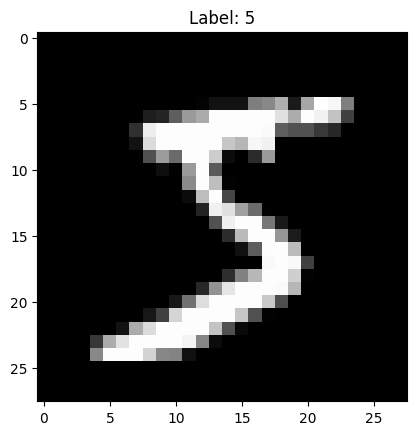

In [4]:
plt.imshow(train_images[0], cmap='gray')
plt.title(f"Label: {train_labels[0]}")
plt.show()

In [5]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [6]:
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

In [7]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu',
                        input_shape=(28,28,1)))

model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))

model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))

model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    train_images,
    train_labels,
    epochs=5,
    validation_data=(test_images, test_labels)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 30ms/step - accuracy: 0.9562 - loss: 0.1410 - val_accuracy: 0.9856 - val_loss: 0.0488
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9860 - loss: 0.0445 - val_accuracy: 0.9891 - val_loss: 0.0338
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9899 - loss: 0.0325 - val_accuracy: 0.9883 - val_loss: 0.0316
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9927 - loss: 0.0228 - val_accuracy: 0.9912 - val_loss: 0.0265
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9944 - loss: 0.0168 - val_accuracy: 0.9907 - val_loss: 0.0281


In [10]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9907 - loss: 0.0281
Test Accuracy: 0.9907000064849854


In [11]:
prediction = model.predict(test_images)

print("Predicted Digit:",
      prediction[0].argmax())

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
Predicted Digit: 7


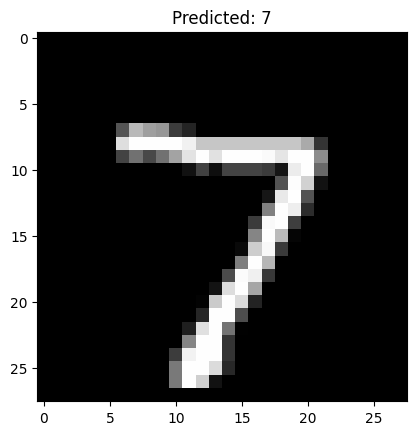

In [12]:
plt.imshow(test_images[0].reshape(28,28), cmap='gray')

plt.title(f"Predicted: {prediction[0].argmax()}")

plt.show()

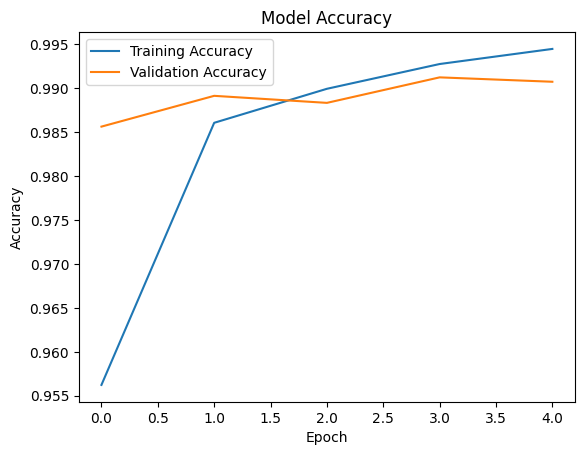

In [13]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

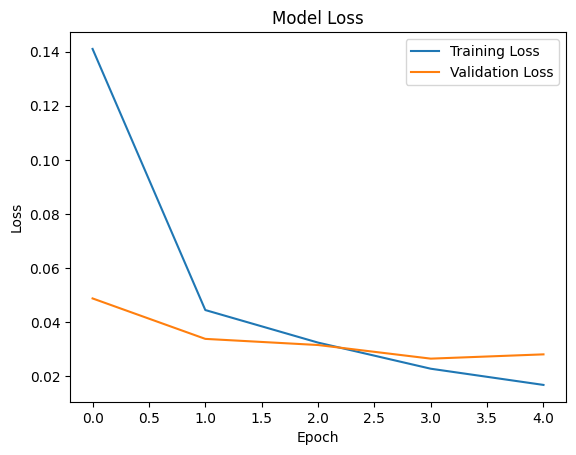

In [14]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

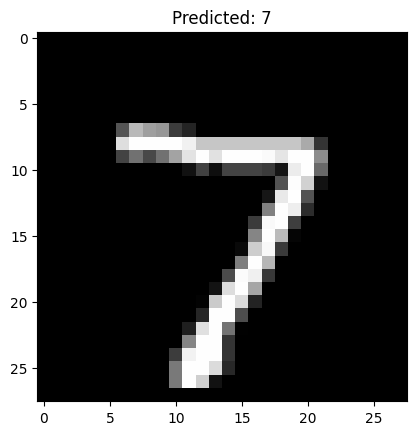

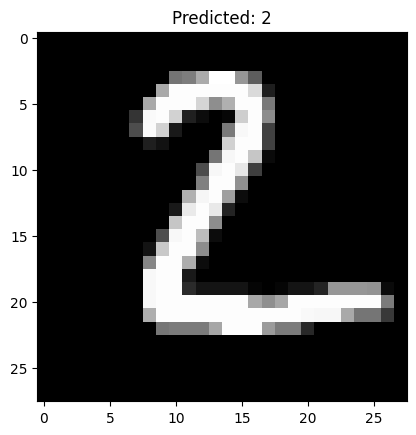

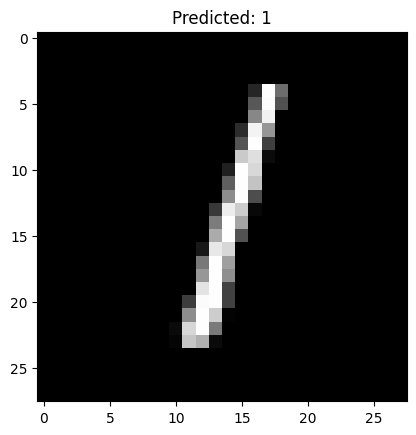

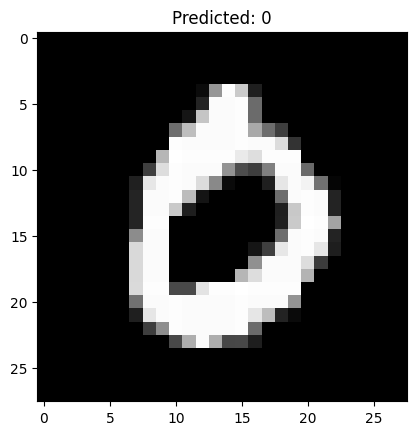

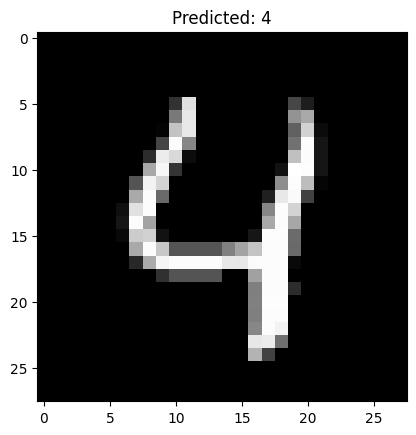

In [15]:
for i in range(5):

    plt.imshow(test_images[i].reshape(28,28), cmap='gray')

    plt.title(f"Predicted: {prediction[i].argmax()}")

    plt.show()

Conclusion

This project uses Convolutional Neural Networks (CNN) to recognize handwritten digits from the MNIST dataset.

The model achieved high accuracy in digit recognition and demonstrated the effectiveness of deep learning in image classification tasks.

This project can be further extended for handwritten word and sentence recognition systems.